In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


In [2]:
df = pd.read_csv("../data/raw/bank_transactions.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/bank_transactions.csv'

In [3]:
import os

os.getcwd()

'C:\\Users\\thais\\OneDrive\\Documentos\\projetos\\bank_transactions_analysis\\notebooks'

In [4]:
import os

os.listdir("../data/raw")

['bank_transactions.csv - bank_transactions_data_2_augmented_clean_2.csv']

In [5]:
df = pd.read_csv("../data/raw/bank_transactions.csv - bank_transactions_data_2_augmented_clean_2.csv")

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [6]:
df = pd.read_csv("../data/raw/bank_transactions.csv")

df.head()


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/bank_transactions.csv'

In [7]:
df = pd.read_csv("../data/raw/bank_transactions.csv")

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  str    
 1   AccountID            50000 non-null  str    
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  str    
 4   TransactionType      50000 non-null  str    
 5   Location             50000 non-null  str    
 6   DeviceID             50000 non-null  str    
 7   IP Address           50000 non-null  str    
 8   MerchantID           50000 non-null  str    
 9   Channel              50000 non-null  str    
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  str    
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), str(10)
memory usage: 

In [9]:
df.shape

(50000, 15)

In [10]:
df.isnull().sum()

TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

ValueError: time data "1/4/2024" doesn't match format "%m/%d/%Y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [14]:
df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"],
    format="mixed",
    errors="coerce"
)

In [15]:
df["TransactionDate"].head()

0   2023-04-11 16:29:00
1   2023-06-27 16:44:00
2   2023-07-10 18:16:00
3   2023-05-05 16:32:00
4   2023-10-16 17:51:00
Name: TransactionDate, dtype: datetime64[us]

In [16]:
df["TransactionDate"].isnull().sum()

np.int64(0)

In [17]:
df["Ano"] = df["TransactionDate"].dt.year
df["Mes"] = df["TransactionDate"].dt.month
df["Dia"] = df["TransactionDate"].dt.day
df["Hora"] = df["TransactionDate"].dt.hour
df["DiaSemana"] = df["TransactionDate"].dt.day_name()

In [18]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Ano,Mes,Dia,Hora,DiaSemana
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2023,4,11,16,Tuesday
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2023,6,27,16,Tuesday
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2023,7,10,18,Monday
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2023,5,5,16,Friday
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2023,10,16,17,Monday


In [19]:
df.to_csv("../data/processed/bank_transactions_clean.csv", index=False)

In [20]:
import sqlite3
import pandas as pd

# Ler a base tratada
df = pd.read_csv("../data/processed/bank_transactions_clean.csv")

# Criar/conectar ao banco SQLite
conn = sqlite3.connect("../database/bank_transactions.db")

# Enviar os dados para uma tabela chamada transactions
df.to_sql("transactions", conn, if_exists="replace", index=False)

# Fechar conexão
conn.close()

print("Banco de dados criado com sucesso!")

Banco de dados criado com sucesso!


In [21]:
conn = sqlite3.connect("../database/bank_transactions.db")

query = """
SELECT *
FROM transactions
LIMIT 5
"""

teste = pd.read_sql_query(query, conn)

conn.close()

teste

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Ano,Mes,Dia,Hora,DiaSemana
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2023,4,11,16,Tuesday
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2023,6,27,16,Tuesday
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2023,7,10,18,Monday
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2023,5,5,16,Friday
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2023,10,16,17,Monday


In [22]:
conn = sqlite3.connect("../database/bank_transactions.db")

query = """
SELECT COUNT(*) AS total_transacoes
FROM transactions
"""

pd.read_sql_query(query, conn)

,total_transacoes
0,50000


In [23]:
query = """
SELECT ROUND(SUM(TransactionAmount), 2) AS valor_total_movimentado
FROM transactions
"""

pd.read_sql_query(query, conn)

,valor_total_movimentado
0,14893610.69


In [24]:
query = """
SELECT ROUND(AVG(TransactionAmount), 2) AS ticket_medio
FROM transactions
"""

pd.read_sql_query(query, conn)

,ticket_medio
0,297.87


In [25]:
query = """
SELECT 
    Channel,
    COUNT(*) AS quantidade_transacoes
FROM transactions
GROUP BY Channel
ORDER BY quantidade_transacoes DESC
"""

pd.read_sql_query(query, conn)

,Channel,quantidade_transacoes
0,Branch,17278
1,ATM,16552
2,Online,16170


In [26]:
query = """
SELECT 
    TransactionType,
    COUNT(*) AS quantidade_transacoes
FROM transactions
GROUP BY TransactionType
ORDER BY quantidade_transacoes DESC
"""

pd.read_sql_query(query, conn)

,TransactionType,quantidade_transacoes
0,Debit,38747
1,Credit,11253


In [27]:
query = """
SELECT 
    Location,
    ROUND(SUM(TransactionAmount), 2) AS valor_total
FROM transactions
GROUP BY Location
ORDER BY valor_total DESC
LIMIT 10
"""

pd.read_sql_query(query, conn)

,Location,valor_total
0,Austin,453508.80
1,Memphis,445646.01
2,Oklahoma City,444559.54
3,San Antonio,423005.49
4,Fort Worth,422279.87
5,Jacksonville,411470.80
6,Phoenix,410725.84
7,Tucson,401159.06
8,Detroit,396371.02
9,Philadelphia,395031.93


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/bank_transactions_clean.csv")

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Ano,Mes,Dia,Hora,DiaSemana
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2023,4,11,16,Tuesday
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2023,6,27,16,Tuesday
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2023,7,10,18,Monday
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2023,5,5,16,Friday
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2023,10,16,17,Monday


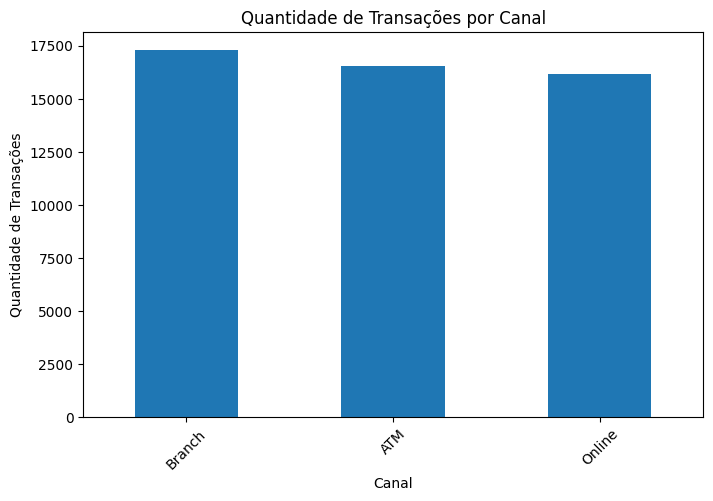

In [29]:
plt.figure(figsize=(8,5))

df["Channel"].value_counts().plot(kind="bar")

plt.title("Quantidade de Transações por Canal")
plt.xlabel("Canal")
plt.ylabel("Quantidade de Transações")
plt.xticks(rotation=45)

plt.show()

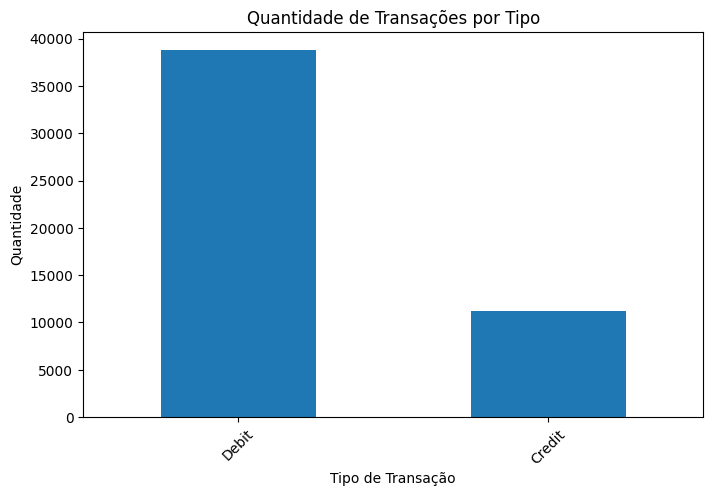

In [30]:
plt.figure(figsize=(8,5))

df["TransactionType"].value_counts().plot(kind="bar")

plt.title("Quantidade de Transações por Tipo")
plt.xlabel("Tipo de Transação")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)

plt.show()

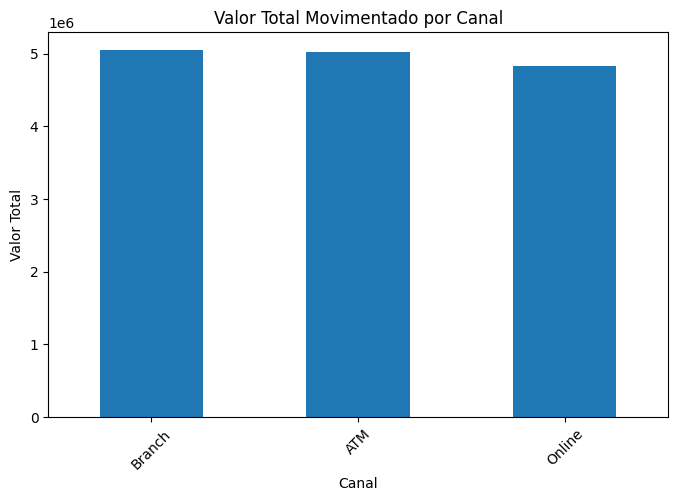

In [31]:
valor_por_canal = df.groupby("Channel")["TransactionAmount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

valor_por_canal.plot(kind="bar")

plt.title("Valor Total Movimentado por Canal")
plt.xlabel("Canal")
plt.ylabel("Valor Total")
plt.xticks(rotation=45)

plt.show()

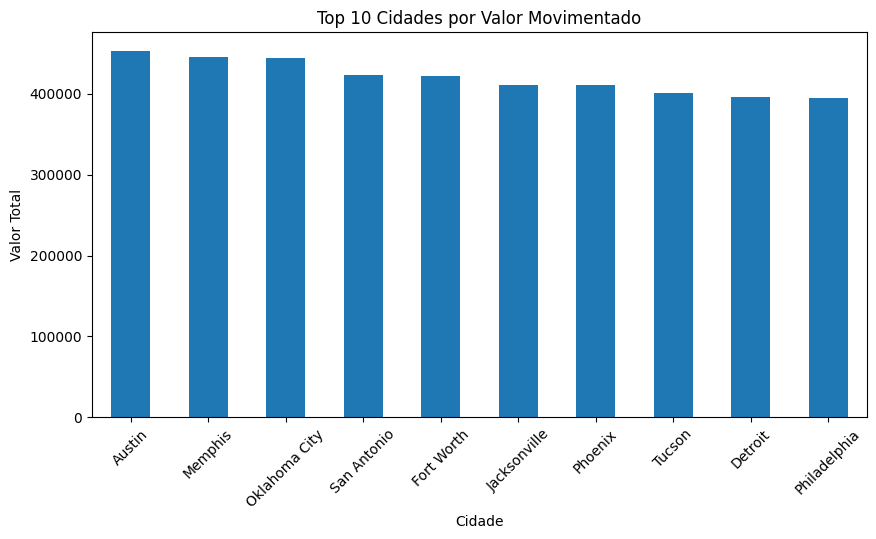

In [32]:
top_cidades = df.groupby("Location")["TransactionAmount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_cidades.plot(kind="bar")

plt.title("Top 10 Cidades por Valor Movimentado")
plt.xlabel("Cidade")
plt.ylabel("Valor Total")
plt.xticks(rotation=45)

plt.show()

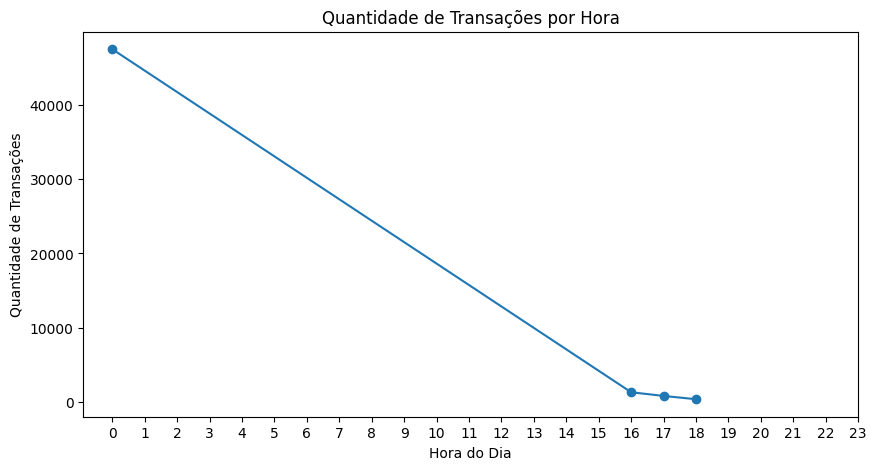

In [33]:
transacoes_hora = df.groupby("Hora")["TransactionID"].count()

plt.figure(figsize=(10,5))

transacoes_hora.plot(kind="line", marker="o")

plt.title("Quantidade de Transações por Hora")
plt.xlabel("Hora do Dia")
plt.ylabel("Quantidade de Transações")
plt.xticks(range(0,24))

plt.show()

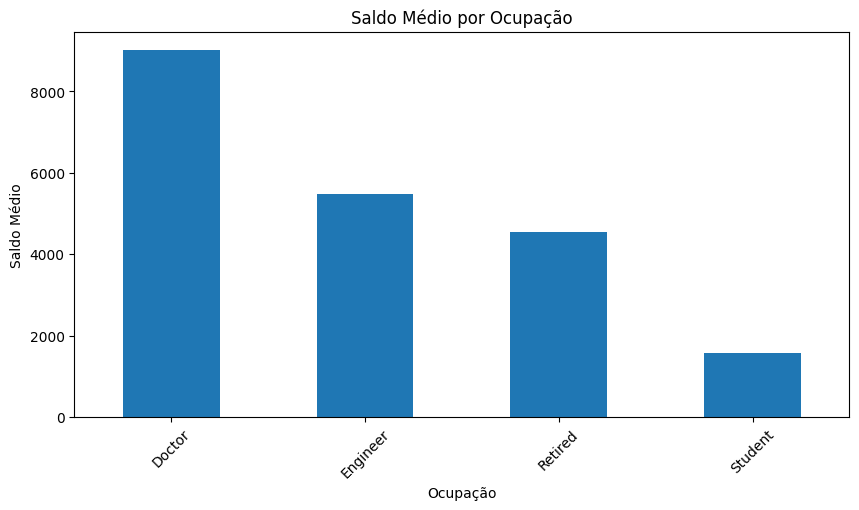

In [34]:
saldo_ocupacao = df.groupby("CustomerOccupation")["AccountBalance"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

saldo_ocupacao.plot(kind="bar")

plt.title("Saldo Médio por Ocupação")
plt.xlabel("Ocupação")
plt.ylabel("Saldo Médio")
plt.xticks(rotation=45)

plt.show()

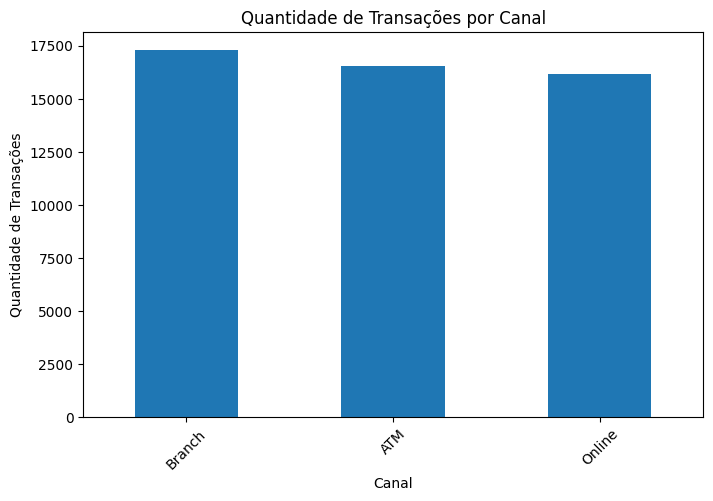

In [35]:
plt.figure(figsize=(8,5))

df["Channel"].value_counts().plot(kind="bar")

plt.title("Quantidade de Transações por Canal")
plt.xlabel("Canal")
plt.ylabel("Quantidade de Transações")
plt.xticks(rotation=45)

plt.savefig("../dashboard/transacoes_por_canal.png", bbox_inches="tight")
plt.show()